In [1]:
import sys
!{sys.executable} -m pip install kagglehub

import sys
!{sys.executable} -m pip install seaborn

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import csv
import math
import random
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt

import json, codecs
import seaborn as sns
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

/Users/fhaz/tf-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Set the path to the file you'd like to load
test_path = "fashion-mnist_test.csv"

# Load the latest version of the test data
test_data = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "zalando-research/fashionmnist",
  test_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", test_data.head())

In [4]:
# Set the path to the file you'd like to load
train_path = "fashion-mnist_train.csv"

# Load the latest version of the train data
train_data = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "zalando-research/fashionmnist",
  train_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", train_data.head())


First 5 records:    label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0  

In [5]:
train_data['label'].describe()
test_data['label'].describe()

#labels range from 0-9

train_data.info() #60000 entries
test_data.info() #10000 entries

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 359.3 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 59.9 MB


In [6]:
X_train = train_data.drop(["label"], axis=1).values
Y_train = train_data.label.values
X_test = test_data.drop(["label"], axis=1).values
Y_test = test_data.label.values

print("X_train shape:", np.shape(X_train))
print("Y_train shape:", np.shape(Y_train))
print("X_test shape:", np.shape(X_test))
print("Y_test shape:", np.shape(X_train))

X_train shape: (60000, 784)
Y_train shape: (60000,)
X_test shape: (10000, 784)
Y_test shape: (60000, 784)


In [7]:
#normalise the data

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

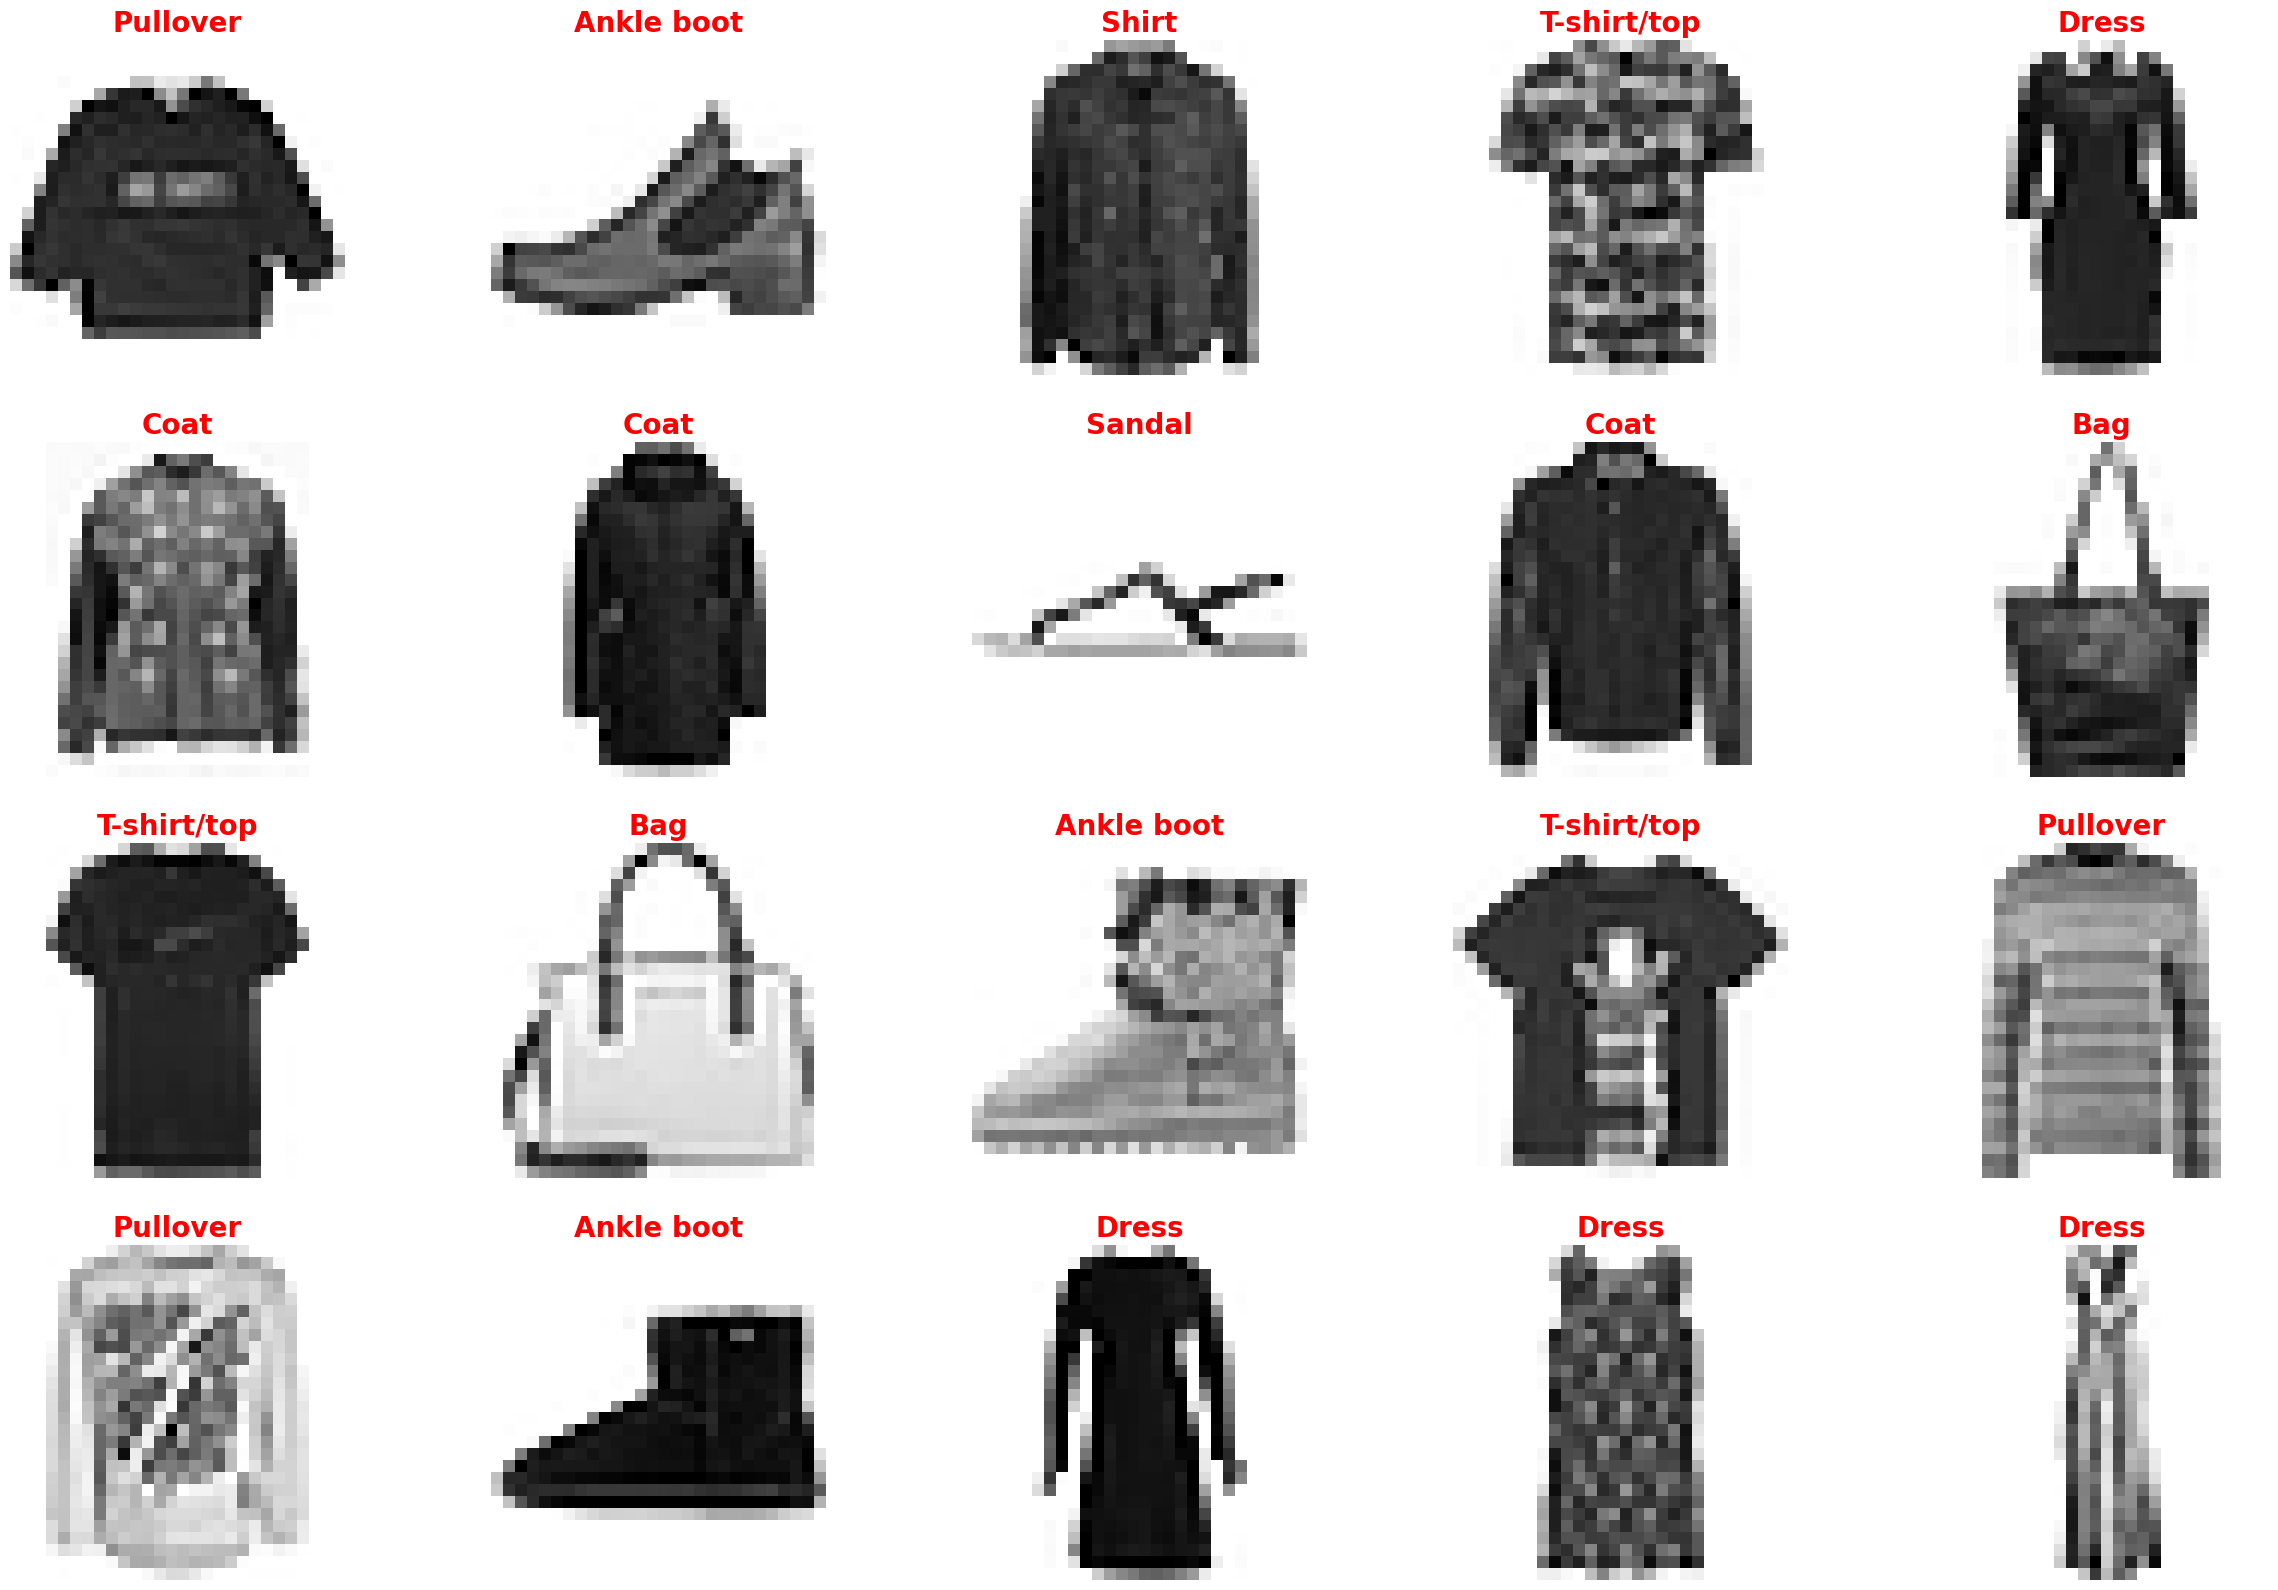

In [8]:
plt.figure(figsize=(30,20))

for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap="gist_yarg")
    plt.title("T-shirt/top" if Y_train[i] == 0 
              else "Trouser" if Y_train[i] == 1
              else "Pullover" if Y_train[i] == 2
              else "Dress" if Y_train[i] == 3
              else "Coat" if Y_train[i] == 4
              else "Sandal" if Y_train[i] == 5
              else "Shirt" if Y_train[i] == 6
              else "Sneaker" if Y_train[i] == 7
              else "Bag" if Y_train[i] == 8
              else "Ankle boot", 
              size = 20, color = "red", fontweight = "bold")
    plt.axis("off")
    
plt.show()

In [9]:
import sys
print(sys.version)

3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]


In [ ]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

input_img = Input(shape = (784,))

In [8]:
encoded = Dense(32, activation="relu")(input_img)
encoded = Dense(16, activation="relu")(encoded)
decoded = Dense(32, activation="relu")(encoded)
decoded = Dense(784, activation="sigmoid")(decoded)

In [9]:
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer="rmsprop", loss="binary_crossentropy")

In [10]:
hist = autoencoder.fit(X_train, 
                       X_train,
                       epochs=250, 
                       batch_size=256, 
                       shuffle=True,
                       validation_data=(X_train, X_train))

NameError: name 'X_train' is not defined